In [1]:
import numpy as np
import matplotlib.pyplot as plt

(-5.0, 5.0)

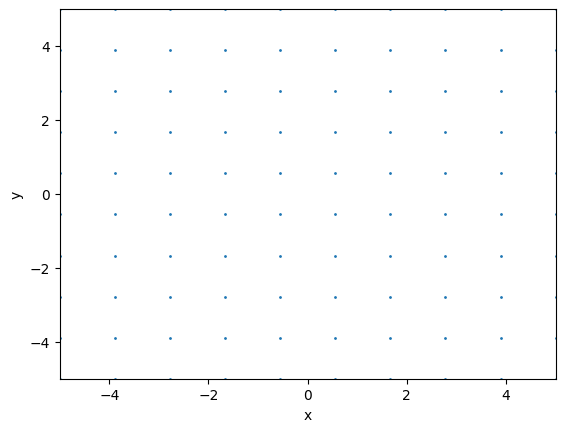

In [2]:
x_grid = np.linspace(-5, 5, 10)
y_grid = np.linspace(-5, 5, 10)
grid = np.array([[x, y] for x in x_grid for y in y_grid])
plt.scatter(grid[:, 0], grid[:, 1], s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-5, 5)
plt.ylim(-5, 5)

[[ 3.53553391 -0.70710678]
 [ 3.53553391  0.70710678]]


(-10.0, 10.0)

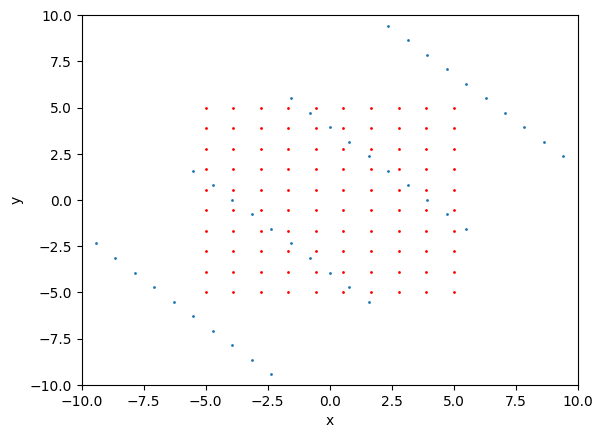

In [3]:
# stretch
stretch = [[5, 0], [0, 1]]
stretch = np.array(stretch)
# rotation
theta = np.radians(45)
rotation = [[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]
rotation = np.array(rotation)
# combined transformation
trans_mat = stretch @ rotation
trans_mat = rotation @ stretch

print(trans_mat)
# apply transformation
transformed_grid = trans_mat @ grid.T

plt.scatter(transformed_grid[0, :], transformed_grid[1, :], s=1)
plt.scatter(grid[:, 0], grid[:, 1], s=1, color='r')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10, 10)
plt.ylim(-10, 10)

In [4]:
sigx = 2
sigy = 1
rho = 0.8
cov = [[sigx**2, rho*sigx*sigy], [rho*sigx*sigy, sigy**2]]

print(cov)

[[4, 1.6], [1.6, 1]]


(-10.0, 10.0)

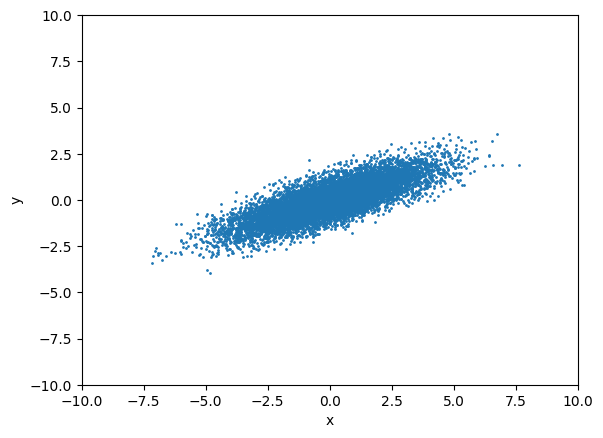

In [5]:
gaussian_grid = np.random.multivariate_normal(mean=[0, 0], cov=cov, size=10000)
plt.scatter(gaussian_grid[:, 0], gaussian_grid[:, 1], s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10, 10)
plt.ylim(-10, 10)

In [6]:
# diagonalize covariance matrix
eigvals, eigvecs = np.linalg.eig(cov)
print(eigvals)
print(eigvecs.T)
eigvecs = eigvecs

# eigvecs_scaled = [[eigvals[i] * eigvecs[i, 0], eigvals[i] * eigvecs[i, 1]] for i in range(len(eigvals))]
# eigvecs_scaled = [[1 * eigvecs[i, 0], 1 * eigvecs[i, 1]] for i in range(len(eigvals))]
eigvecs_scaled = [[5 * eigvecs[0, 0], 1 * eigvecs[0, 1]], [5 * eigvecs[1, 0], 1 * eigvecs[1, 1]]] 
eigvecs_scaled = [[eigvals[0] * eigvecs[0, 0], eigvals[1] * eigvecs[0, 1]], [eigvals[0] * eigvecs[1, 0], eigvals[1] * eigvecs[1, 1]]] 
eigvecs_scaled = [[eigvals[0] * eigvecs[0, 0], 1 * eigvecs[0, 1]], [eigvals[0] * eigvecs[1, 0], 1 * eigvecs[1, 1]]] 

eigvecs_scaled = np.array(eigvecs_scaled)

[4.69317122 0.30682878]
[[ 0.91758954  0.39752916]
 [-0.39752916  0.91758954]]


In [7]:
print(eigvecs_scaled)

[[ 4.30640482 -0.39752916]
 [ 1.86567243  0.91758954]]


dot product of eigvecs: 0.0


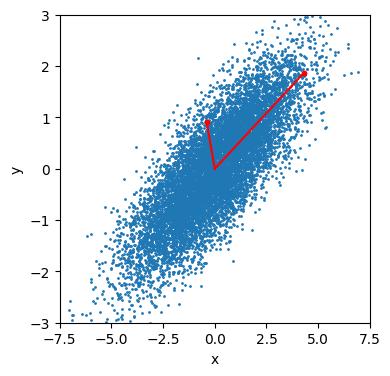

In [8]:
# add eig vectors to plot
plt.figure(figsize=(4, 4))
plt.scatter(gaussian_grid[:, 0], gaussian_grid[:, 1], s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-7.5, 7.5)
plt.ylim(-10, 10)
plt.ylim(-7.5, 7.5)
plt.ylim(-3, 3)
# plt.scatter(eigvecs[0, :], eigvecs[1, :], s=100, color='r')
plt.scatter(eigvecs_scaled[0, :], eigvecs_scaled[1, :], s=10, color='r')
# draw lines from center to eigvecs
plt.plot([0, eigvecs_scaled[0, 0]], [0, eigvecs_scaled[1, 0]], color='r')
plt.plot([0, eigvecs_scaled[0, 1]], [0, eigvecs_scaled[1, 1]], color='r')

print("dot product of eigvecs:", np.dot(eigvecs[:, 0], eigvecs[:, 1]))


In [9]:
import getdist.plots as gdplt
from cobaya import load_samples

In [10]:
gd_sample = load_samples(r'..\cobaya_runs\DESI_data\base_w_wa\run1', to_getdist=True, skip=0.33)

var_names = ['w', 'wa']

((np.float64(-1.4572605435653), np.float64(0.22845126456530032)),
 (-3.0, np.float64(1.760402515729266)))

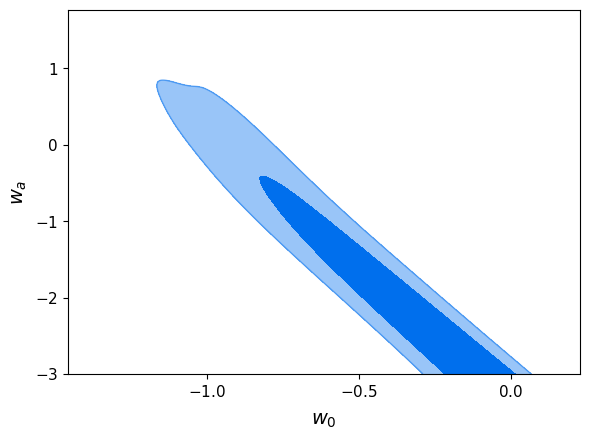

In [11]:
gdplot = gdplt.get_single_plotter()
gdplot.plot_2d(gd_sample, var_names[0], var_names[1], filled=True)

In [12]:
# Get covariance matrix for w0 and wa
cov = gd_sample.cov(pars=['w', 'wa'])
print(cov)

corr = gd_sample.corr(pars=['w', 'wa'])
print(corr)

[[ 0.07702357 -0.26349246]
 [-0.26349246  0.97289806]]
[[ 1.         -0.96254867]
 [-0.96254867  1.        ]]


In [13]:
mean_w  = gd_sample.mean('w')
mean_wa = gd_sample.mean('wa')
print(mean_w, mean_wa)

-0.47875321053366265 -1.6580652194691066


Text(0, 0.5, '$w_a$')

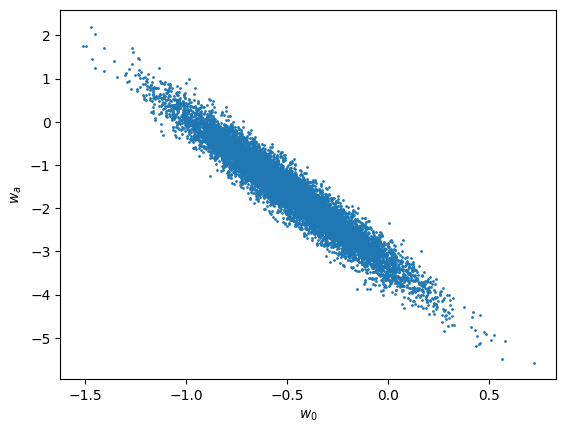

In [14]:
# gaussian grid centered on mean
gaussian_grid = np.random.multivariate_normal(mean=[mean_w, mean_wa], cov=cov, size=10000)
plt.scatter(gaussian_grid[:, 0], gaussian_grid[:, 1], s=1)
plt.xlabel(r'$w_0$')
plt.ylabel(r'$w_a$')

(-4.0, 2.0)

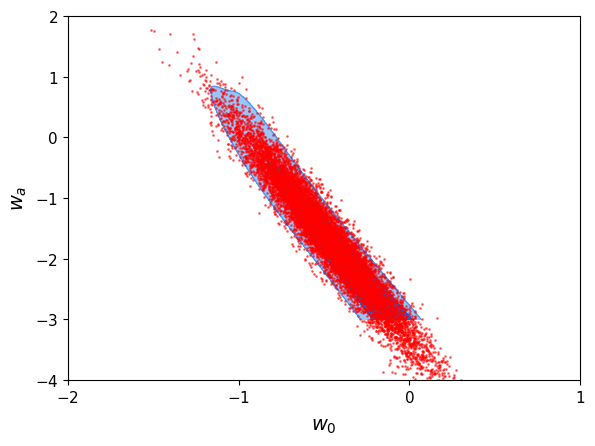

In [15]:
gdplot = gdplt.get_single_plotter()
gdplot.plot_2d(gd_sample, var_names[0], var_names[1], filled=True)
plt.scatter(gaussian_grid[:, 0], gaussian_grid[:, 1], s=1, alpha=0.5, color='r')
plt.xlim(-2, 1)
plt.ylim(-4, 2)

In [25]:
# linear fit on the points
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(gaussian_grid[:, 0], gaussian_grid[:, 1])
print("slope:", slope)

from scipy.optimize import curve_fit
def linear_model(x, a):
    return a * (x + 1) 

popt, pcov = curve_fit(linear_model, gaussian_grid[:, 0], gaussian_grid[:, 1])
print("optimal parameter:", popt[0])

slope: -3.415449466636342
optimal parameter: -3.235344445040476


degeneracy line : wa = -3.4 * w0 + -3.3


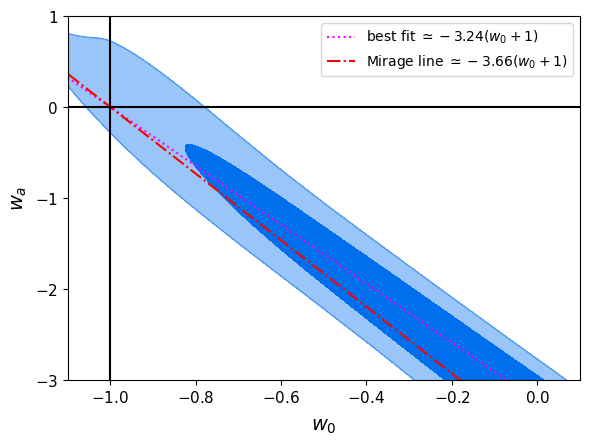

In [35]:
gdplot = gdplt.get_single_plotter()
gdplot.plot_2d(gd_sample, var_names[0], var_names[1], filled=True)
# plt.scatter(gaussian_grid[:, 0], gaussian_grid[:, 1], s=1, alpha=0.5, color='r')

x_fit = np.linspace(-2, 1, 100)
y_fit = slope * x_fit + intercept   
# plt.plot(x_fit, y_fit, color='k', ls='--', label='linear fit')
y_fit = popt[0] * (x_fit + 1)
plt.plot(x_fit, y_fit, color='magenta', ls=':', label=rf'best fit $\simeq {popt[0]:.2f} (w_0 + 1)$')
y_fit = -2.85 * x_fit - 2.92
# plt.plot(x_fit, y_fit, color='r', ls=':', label='CMB+BAO')
y_fit = -3.66 * x_fit - 3.66
plt.plot(x_fit, y_fit, color='r', ls='-.', label=r'Mirage line $\simeq -3.66 (w_0 + 1)$')

plt.axhline(0, color='k', ls='-')
plt.axvline(-1, color='k', ls='-')

plt.xlim(-1.1, 0.1)
plt.ylim(-3, 1)
plt.legend()


print("degeneracy line : wa =", round(slope, 1), "* w0 +", round(intercept, 1))